## Exploratory Data Analysis

The dataset is not perfectly clean or balanced because it combines automatically labeled COCO data with manually labeled Roboflow images.

Main observations:
- The dataset contains 80 object classes.
- Some classes appear much more than others, causing class imbalance.
- The images contain objects with different sizes, including small objects that are harder to detect.
- The dataset includes real-world backgrounds, occlusion, and different lighting conditions.
- Because the dataset combines automatic and manual annotations, minor label noise may exist.

These findings support using YOLOv8 transfer learning and fine-tuning instead of training only from scratch.

In [ ]:

!pip install -q ultralytics pycocotools kaggle

import os
import shutil
import random
import time
from pathlib import Path

import yaml
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pycocotools.coco import COCO
from ultralytics import YOLO

random.seed(42)
np.random.seed(42)

In [ ]:

from google.colab import files

uploaded = files.upload()

Saving Manual_label.yolov8.zip to Manual_label.yolov8 (1).zip


In [ ]:

!unzip -q Manual_label.yolov8.zip -d /content/

!find /content -name "data.yaml"

replace /content/train/images/WhatsApp Image 2026-05-16 at 3-17-32 PM (1)_jpeg.rf.XvUk8CIwY7ryXHPGYy9A.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
/content/data.yaml


In [ ]:

from google.colab import files

files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"karimdeheya","key":"4758eda8855969d969396a6844199917"}'}

In [ ]:

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d awsaf49/coco-2017-dataset -p /content/
!unzip -q /content/coco-2017-dataset.zip -d /content/

!find /content -name "instances_train2017.json"
!find /content -name "instances_val2017.json"

Dataset URL: https://www.kaggle.com/datasets/awsaf49/coco-2017-dataset
License(s): CC-BY-SA-4.0
Resuming from 14800650240 bytes (12083711925 bytes left)...
100% 25.0G/25.0G [10:45<00:00, 18.7MB/s]

/content/coco2017/annotations/instances_train2017.json
/content/coco2017/annotations/instances_val2017.json


In [ ]:

COCO_ROOT = Path('/content/coco2017')

TRAIN_IMAGES_DIR = COCO_ROOT / 'train2017'
VAL_IMAGES_DIR = COCO_ROOT / 'val2017'
ANNOTATIONS_DIR = COCO_ROOT / 'annotations'

TRAIN_ANN_FILE = ANNOTATIONS_DIR / 'instances_train2017.json'
VAL_ANN_FILE = ANNOTATIONS_DIR / 'instances_val2017.json'


MANUAL_DATASET_DIR = Path('/content')


FINAL_DATASET_DIR = Path('/content/final_coco_plus_manual')


MAX_TRAIN_IMAGES = None
MAX_VAL_IMAGES = None

print("COCO train images:", TRAIN_IMAGES_DIR.exists())
print("COCO val images:", VAL_IMAGES_DIR.exists())
print("COCO train ann:", TRAIN_ANN_FILE.exists())
print("COCO val ann:", VAL_ANN_FILE.exists())
print("Manual dataset:", MANUAL_DATASET_DIR.exists())

In [ ]:
!find /content -type d -name "*Manual*"
!find /content -type d -name "*manual*"
!find /content -name "data.yaml"

/content/data.yaml


In [ ]:

def coco_bbox_to_yolo(bbox, img_width, img_height):
    x, y, w, h = bbox

    x_center = (x + w / 2) / img_width
    y_center = (y + h / 2) / img_height
    width = w / img_width
    height = h / img_height

    return x_center, y_center, width, height

In [ ]:

def prepare_coco_all_classes(ann_file, images_dir, split_name, max_images=None):
    coco = COCO(str(ann_file))

    cat_ids = coco.getCatIds()
    cats = coco.loadCats(cat_ids)

    cat_id_to_yolo_id = {cat['id']: i for i, cat in enumerate(cats)}
    class_names = [cat['name'] for cat in cats]

    img_ids = coco.getImgIds()
    random.shuffle(img_ids)

    if max_images is not None:
        img_ids = img_ids[:max_images]

    out_img_dir = FINAL_DATASET_DIR / split_name / 'images'
    out_lbl_dir = FINAL_DATASET_DIR / split_name / 'labels'

    out_img_dir.mkdir(parents=True, exist_ok=True)
    out_lbl_dir.mkdir(parents=True, exist_ok=True)

    copied_images = 0
    total_boxes = 0

    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        file_name = img_info['file_name']
        img_w = img_info['width']
        img_h = img_info['height']

        ann_ids = coco.getAnnIds(imgIds=[img_id], iscrowd=False)
        anns = coco.loadAnns(ann_ids)

        label_lines = []

        for ann in anns:
            if 'bbox' not in ann:
                continue

            old_cat_id = ann['category_id']
            if old_cat_id not in cat_id_to_yolo_id:
                continue

            class_id = cat_id_to_yolo_id[old_cat_id]

            x_center, y_center, width, height = coco_bbox_to_yolo(
                ann['bbox'], img_w, img_h
            )

            if width <= 0 or height <= 0:
                continue

            label_lines.append(
                f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
            )

        if not label_lines:
            continue

        src_img = images_dir / file_name
        dst_img = out_img_dir / file_name
        dst_lbl = out_lbl_dir / f"{Path(file_name).stem}.txt"

        if src_img.exists():
            shutil.copy2(src_img, dst_img)

            with open(dst_lbl, 'w') as f:
                f.write('\n'.join(label_lines))

            copied_images += 1
            total_boxes += len(label_lines)

    print(f"{split_name}: copied {copied_images} images with {total_boxes} boxes")
    return class_names, copied_images, total_boxes

In [ ]:


MAX_TRAIN_IMAGES = 20000
MAX_VAL_IMAGES = 3000

if FINAL_DATASET_DIR.exists():
    shutil.rmtree(FINAL_DATASET_DIR)

CLASS_NAMES, train_count, train_boxes = prepare_coco_all_classes(
    TRAIN_ANN_FILE,
    TRAIN_IMAGES_DIR,
    'train',
    MAX_TRAIN_IMAGES
)

_, val_count, val_boxes = prepare_coco_all_classes(
    VAL_ANN_FILE,
    VAL_IMAGES_DIR,
    'val',
    MAX_VAL_IMAGES
)

print("COCO full dataset created.")
print("Number of classes:", len(CLASS_NAMES))
print("Train images:", train_count)
print("Val images:", val_count)
print(CLASS_NAMES)

loading annotations into memory...
Done (t=14.64s)
creating index...
index created!
train: copied 19827 images with 143892 boxes
loading annotations into memory...
Done (t=0.84s)
creating index...
index created!
val: copied 2972 images with 21747 boxes
COCO full dataset created.
Number of classes: 80
Train images: 19827
Val images: 2972
['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toil

In [ ]:

manual_train_images = MANUAL_DATASET_DIR / 'train/images'
manual_train_labels = MANUAL_DATASET_DIR / 'train/labels'

final_train_images = FINAL_DATASET_DIR / 'train/images'
final_train_labels = FINAL_DATASET_DIR / 'train/labels'

coco_name_to_id = {name: idx for idx, name in enumerate(CLASS_NAMES)}

ROBOFLOW_TO_COCO_NAME = {
    0: 'bus',
    1: 'car',
    2: 'motorcycle',
    3: 'truck'
}

ROBOFLOW_TO_COCO_ID = {
    old_id: coco_name_to_id[name]
    for old_id, name in ROBOFLOW_TO_COCO_NAME.items()
}

print("Roboflow to COCO ID mapping:")
print(ROBOFLOW_TO_COCO_ID)

manual_img_count = 0
manual_lbl_count = 0

if manual_train_images.exists() and manual_train_labels.exists():

    for img in manual_train_images.glob('*'):
        if img.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']:
            new_img_name = "manual_" + img.name
            shutil.copy2(img, final_train_images / new_img_name)
            manual_img_count += 1

    for lbl in manual_train_labels.glob('*.txt'):
        new_lines = []

        with open(lbl, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            old_class_id = int(parts[0])

            if old_class_id in ROBOFLOW_TO_COCO_ID:
                new_class_id = ROBOFLOW_TO_COCO_ID[old_class_id]
                parts[0] = str(new_class_id)
                new_lines.append(" ".join(parts))

        new_label_name = "manual_" + lbl.name

        with open(final_train_labels / new_label_name, 'w') as f:
            f.write("\n".join(new_lines))

        manual_lbl_count += 1

    print("Manual Roboflow dataset merged successfully.")
    print("Manual images added:", manual_img_count)
    print("Manual labels added:", manual_lbl_count)

else:
    print("Manual dataset path not found. Check MANUAL_DATASET_DIR.")

Roboflow to COCO ID mapping:
{0: 5, 1: 2, 2: 3, 3: 7}
Manual Roboflow dataset merged successfully.
Manual images added: 98
Manual labels added: 98


In [ ]:

data_yaml = {
    'path': str(FINAL_DATASET_DIR),
    'train': 'train/images',
    'val': 'val/images',
    'nc': len(CLASS_NAMES),
    'names': CLASS_NAMES
}

DATA_YAML_PATH = FINAL_DATASET_DIR / 'data.yaml'

with open(DATA_YAML_PATH, 'w') as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print(yaml.dump(data_yaml, sort_keys=False))

path: /content/final_coco_plus_manual
train: train/images
val: val/images
nc: 80
names:
- person
- bicycle
- car
- motorcycle
- airplane
- bus
- train
- truck
- boat
- traffic light
- fire hydrant
- stop sign
- parking meter
- bench
- bird
- cat
- dog
- horse
- sheep
- cow
- elephant
- bear
- zebra
- giraffe
- backpack
- umbrella
- handbag
- tie
- suitcase
- frisbee
- skis
- snowboard
- sports ball
- kite
- baseball bat
- baseball glove
- skateboard
- surfboard
- tennis racket
- bottle
- wine glass
- cup
- fork
- knife
- spoon
- bowl
- banana
- apple
- sandwich
- orange
- broccoli
- carrot
- hot dog
- pizza
- donut
- cake
- chair
- couch
- potted plant
- bed
- dining table
- toilet
- tv
- laptop
- mouse
- remote
- keyboard
- cell phone
- microwave
- oven
- toaster
- sink
- refrigerator
- book
- clock
- vase
- scissors
- teddy bear
- hair drier
- toothbrush



In [ ]:

def count_images(folder):
    folder = Path(folder)
    return len([
        p for p in folder.glob('*')
        if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']
    ])

def count_labels(folder):
    return len(list(Path(folder).glob('*.txt')))

summary = pd.DataFrame({
    'Split': ['Train', 'Validation'],
    'Images': [
        count_images(FINAL_DATASET_DIR / 'train/images'),
        count_images(FINAL_DATASET_DIR / 'val/images')
    ],
    'Labels': [
        count_labels(FINAL_DATASET_DIR / 'train/labels'),
        count_labels(FINAL_DATASET_DIR / 'val/labels')
    ]
})

summary

,Split,Images,Labels
0,Train,19925,19925
1,Validation,2972,2972


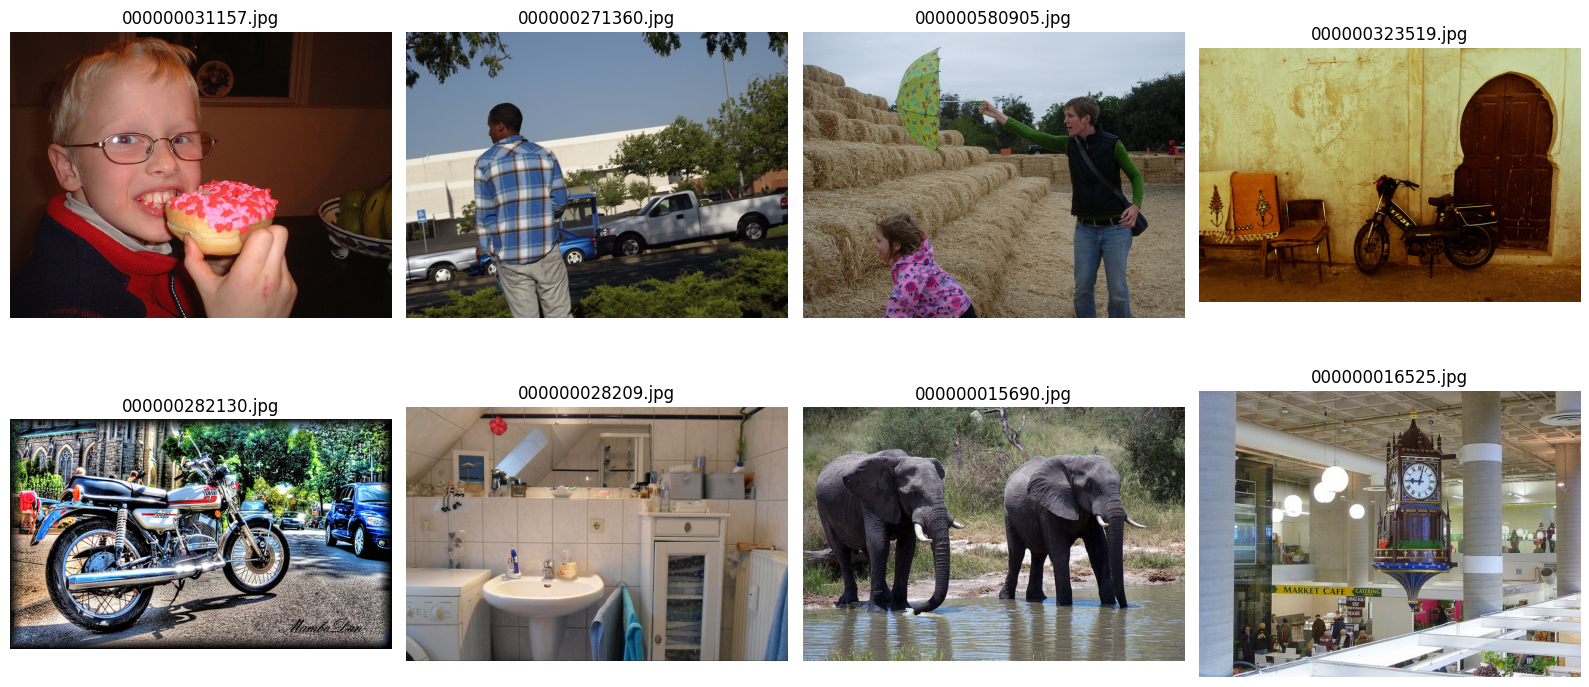

In [ ]:


sample_images = list((FINAL_DATASET_DIR / 'train/images').glob('*'))
sample_images = [
    p for p in sample_images
    if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']
]

random_samples = random.sample(sample_images, min(8, len(sample_images)))

plt.figure(figsize=(16, 8))

for i, img_path in enumerate(random_samples):
    img = Image.open(img_path)
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path.name[:20])

plt.tight_layout()
plt.show()


image 1/1 /content/final_coco_plus_manual/train/images/000000031157.jpg: 480x640 1 person, 1 bowl, 1 banana, 1 donut, 147.8ms
Speed: 20.0ms preprocess, 147.8ms inference, 84.0ms postprocess per image at shape (1, 3, 480, 640)


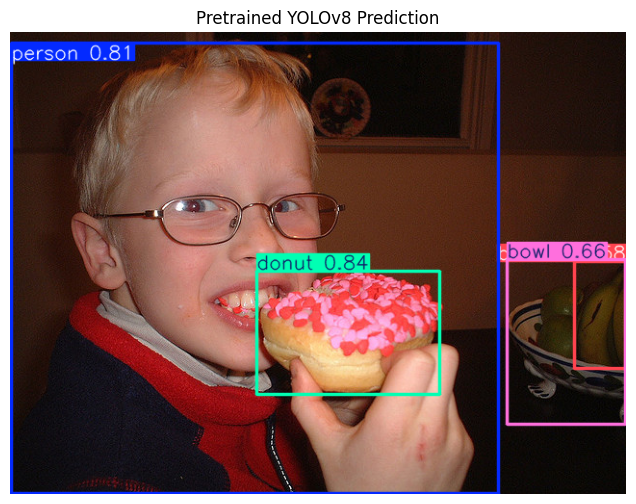


image 1/1 /content/final_coco_plus_manual/train/images/000000271360.jpg: 480x640 1 person, 1 truck, 10.0ms
Speed: 1.8ms preprocess, 10.0ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


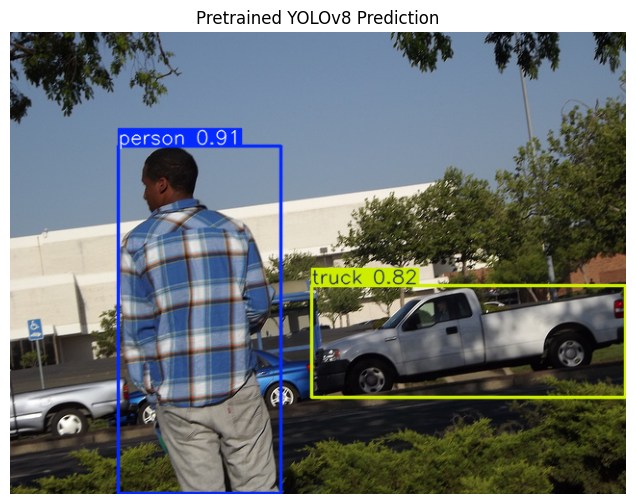


image 1/1 /content/final_coco_plus_manual/train/images/000000580905.jpg: 512x640 2 persons, 67.5ms
Speed: 1.9ms preprocess, 67.5ms inference, 1.5ms postprocess per image at shape (1, 3, 512, 640)


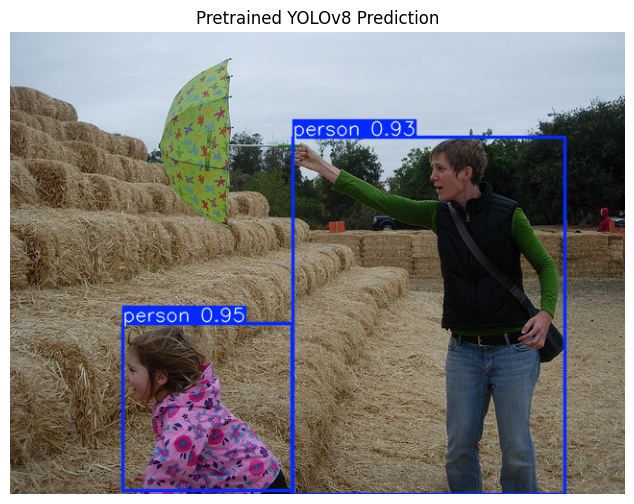

In [ ]:

pretrained_model = YOLO('yolov8n.pt')

for img_path in random_samples[:3]:
    results = pretrained_model.predict(
        source=str(img_path),
        imgsz=640,
        conf=0.4
    )

    plotted = results[0].plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(plotted)
    plt.axis('off')
    plt.title('Pretrained YOLOv8 Prediction')
    plt.show()

In [ ]:

IMG_SIZE = 640
BATCH_SIZE = 16
EPOCHS_SCRATCH = 5

start = time.time()

model_scratch = YOLO('yolov8n.yaml')

results_scratch = model_scratch.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS_SCRATCH,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=0,
    project='/content/runs_object_detection_project',
    name='scratch_yolov8n',
    exist_ok=True
)

scratch_time = (time.time() - start) / 60
print(f"Scratch training time: {scratch_time:.2f} minutes")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_coco_plus_manual/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=scratch_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [ ]:

EPOCHS_TRANSFER = 20

start = time.time()

model_transfer = YOLO('yolov8n.pt')

results_transfer = model_transfer.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS_TRANSFER,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=0,
    project='/content/runs_object_detection_project',
    name='transfer_yolov8n',
    exist_ok=True
)

transfer_time = (time.time() - start) / 60
print(f"Transfer learning time: {transfer_time:.2f} minutes")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_coco_plus_manual/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=transfer_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [ ]:

EPOCHS_FINETUNE = 10

transfer_best_path = '/content/runs_object_detection_project/transfer_yolov8n/weights/best.pt'

start = time.time()

model_finetune = YOLO(transfer_best_path)

results_finetune = model_finetune.train(
    data=str(DATA_YAML_PATH),
    epochs=EPOCHS_FINETUNE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    device=0,
    lr0=0.0001,
    project='/content/runs_object_detection_project',
    name='finetuned_yolov8n',
    exist_ok=True
)

finetune_time = (time.time() - start) / 60
print(f"Fine-tuning time: {finetune_time:.2f} minutes")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/final_coco_plus_manual/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/runs_object_detection_project/transfer_yolov8n/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetuned_yolov8n, nbs=64, nms=

In [ ]:

def evaluate_model(weights_path, model_name, train_time):
    model = YOLO(weights_path)

    metrics = model.val(
        data=str(DATA_YAML_PATH),
        imgsz=IMG_SIZE,
        batch=BATCH_SIZE,
        device=0
    )

    return {
        'Model': model_name,
        'Precision': float(metrics.box.mp),
        'Recall': float(metrics.box.mr),
        'mAP50': float(metrics.box.map50),
        'mAP50-95': float(metrics.box.map),
        'Training Time (min)': round(train_time, 2),
        'Weights Path': weights_path
    }

comparison_results = []

comparison_results.append(
    evaluate_model(
        '/content/runs_object_detection_project/scratch_yolov8n/weights/best.pt',
        'YOLOv8n From Scratch',
        scratch_time
    )
)

comparison_results.append(
    evaluate_model(
        '/content/runs_object_detection_project/transfer_yolov8n/weights/best.pt',
        'YOLOv8n Transfer Learning',
        transfer_time
    )
)

comparison_results.append(
    evaluate_model(
        '/content/runs_object_detection_project/finetuned_yolov8n/weights/best.pt',
        'YOLOv8n Fine-Tuned',
        finetune_time
    )
)

comparison_df = pd.DataFrame(comparison_results)
comparison_df

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2405.7±309.5 MB/s, size: 140.2 KB)
val: Scanning /content/final_coco_plus_manual/val/labels.cache... 2972 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2972/2972 958.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 186/186 6.2it/s 30.1s
                   all       2972      21747      0.564     0.0136    0.00852    0.00334
                person       1620       6524      0.144      0.256      0.118     0.0428
               bicycle         85        192          1          0   0.000176   2.48e-05
                   car        314       1148      0.104     0.0139    0.00718    0.00201
            motorcycle         95        240     0.0639     0.0208    0.00847     0.0026
              airplane    

,Model,Precision,Recall,mAP50,mAP50-95,Training Time (min),Weights Path
0,YOLOv8n From Scratch,0.563508,0.013587,0.008516,0.003335,34.94,/content/runs_object_detection_project/scratch...
1,YOLOv8n Transfer Learning,0.607805,0.454917,0.489684,0.339625,127.93,/content/runs_object_detection_project/transfe...
2,YOLOv8n Fine-Tuned,0.604292,0.458367,0.489508,0.341918,67.74,/content/runs_object_detection_project/finetun...


In [ ]:

best_row = comparison_df.sort_values(by='mAP50-95', ascending=False).iloc[0]

BEST_MODEL_PATH = best_row['Weights Path']

print("Best model:", best_row['Model'])
print("Best model path:", BEST_MODEL_PATH)

DEPLOY_MODEL_PATH = '/content/best_coco_manual_yolov8.pt'

shutil.copy2(BEST_MODEL_PATH, DEPLOY_MODEL_PATH)

print("Deployment model saved to:", DEPLOY_MODEL_PATH)

Best model: YOLOv8n Fine-Tuned
Best model path: /content/runs_object_detection_project/finetuned_yolov8n/weights/best.pt
Deployment model saved to: /content/best_coco_manual_yolov8.pt



image 1/1 /content/final_coco_plus_manual/val/images/000000028809.jpg: 640x640 2 bowls, 4 bananas, 8.4ms
Speed: 5.4ms preprocess, 8.4ms inference, 6.6ms postprocess per image at shape (1, 3, 640, 640)


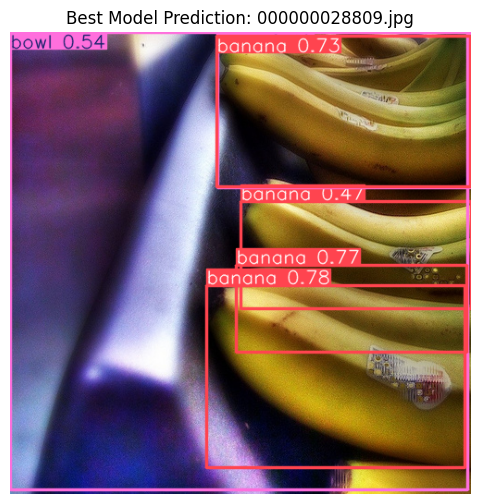


image 1/1 /content/final_coco_plus_manual/val/images/000000199681.jpg: 480x640 1 cell phone, 17.0ms
Speed: 1.9ms preprocess, 17.0ms inference, 5.8ms postprocess per image at shape (1, 3, 480, 640)


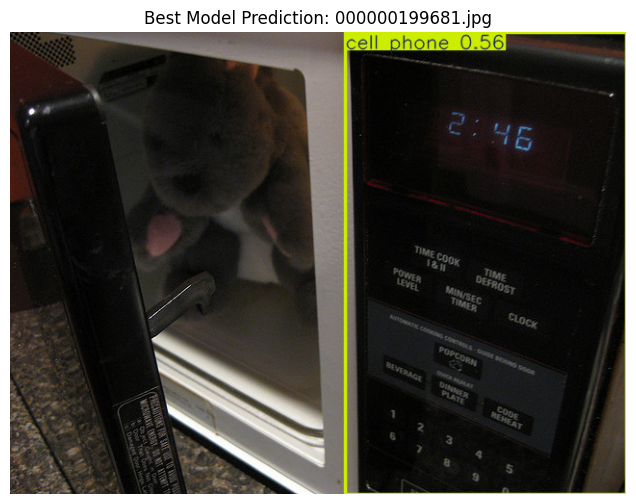


image 1/1 /content/final_coco_plus_manual/val/images/000000457078.jpg: 480x640 1 person, 1 cup, 1 tv, 10.1ms
Speed: 1.9ms preprocess, 10.1ms inference, 1.7ms postprocess per image at shape (1, 3, 480, 640)


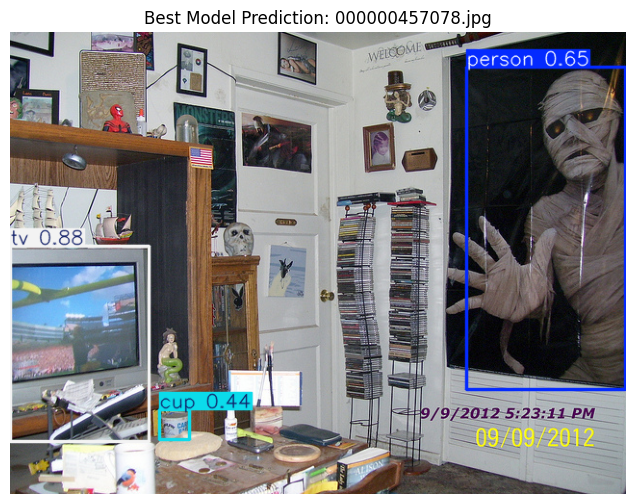


image 1/1 /content/final_coco_plus_manual/val/images/000000247838.jpg: 448x640 9 sheeps, 92.1ms
Speed: 2.4ms preprocess, 92.1ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


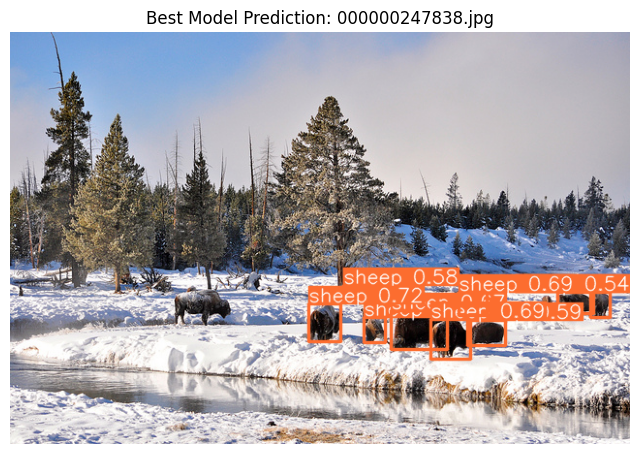


image 1/1 /content/final_coco_plus_manual/val/images/000000376856.jpg: 640x480 1 clock, 71.7ms
Speed: 2.0ms preprocess, 71.7ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 480)


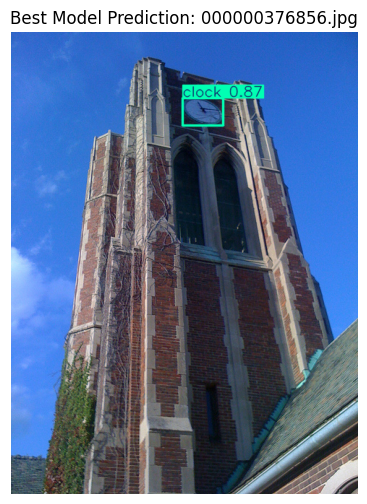


image 1/1 /content/final_coco_plus_manual/val/images/000000269314.jpg: 480x640 1 bird, 11.2ms
Speed: 2.2ms preprocess, 11.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


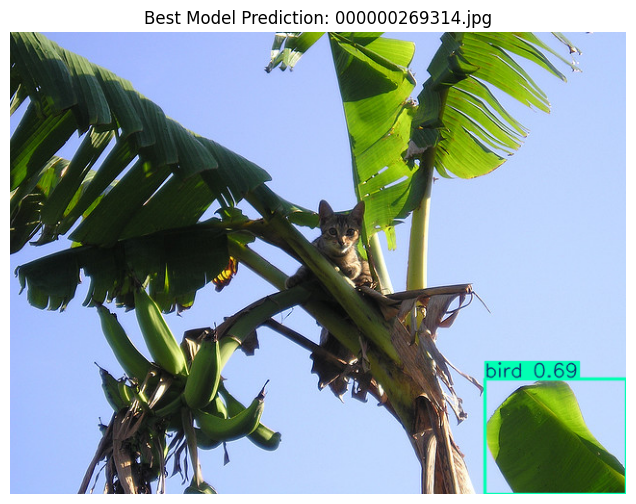

In [ ]:

best_model = YOLO(DEPLOY_MODEL_PATH)

val_images = list((FINAL_DATASET_DIR / 'val/images').glob('*'))
val_images = [
    p for p in val_images
    if p.suffix.lower() in ['.jpg', '.jpeg', '.png', '.webp']
]

test_samples = random.sample(val_images, min(6, len(val_images)))

for img_path in test_samples:
    results = best_model.predict(
        source=str(img_path),
        imgsz=IMG_SIZE,
        conf=0.4
    )

    plotted = results[0].plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 6))
    plt.imshow(plotted)
    plt.axis('off')
    plt.title(f"Best Model Prediction: {img_path.name}")
    plt.show()

In [ ]:

best_model.export(format='onnx')

!zip -r object_detection_outputs.zip /content/best_coco_manual_yolov8.pt /content/runs_object_detection_project /content/final_coco_plus_manual/data.yaml

from google.colab import files

files.download('/content/best_coco_manual_yolov8.pt')
files.download('/content/object_detection_outputs.zip')

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/best_coco_manual_yolov8.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (6.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 208ms
Prepared 4 packages in 7.57s
Installed 4 packages in 313ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.26.0
 + onnxslim==0.1.93

requirements: AutoUpdate success ✅ 9.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 11.0s, saved as '/content/best_coco_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>